# 12 · Training a QBM end-to-end on variationally prepared states

Notebook 11 built a Gibbs state with VarQITE. This one puts that inside a **training
loop**: at every optimisation step the thermal state $\rho(\theta)$ is rebuilt by a
variational circuit, from expectation values, with no eigendecomposition anywhere in the
loop. Then $\theta$ is updated from a measured gradient and we go again.

That is the full device-native pipeline, and this notebook is the guide to running it —
including the two places it bites, and what to do about them.

## The recipe

```python
from qbm.backends.circuit import CircuitBackend

backend = CircuitBackend(gibbs_prep="varqite",
                         varqite_options={"depth": 3, "steps": 40})
model   = qbm.learn(data, backend=backend, steps=60)
```

Three knobs, and they trade the same currency (circuits) for different things:

| knob | what it buys | typical |
|---|---|---|
| `varqite_options["depth"]` | how much of the imaginary-time flow the ansatz can represent | 2–4 |
| `varqite_options["steps"]` | the ODE discretisation of that flow | 25–100 |
| `shots` | statistical resolution of every measured quantity | `None`, or $10^3$–$10^4$ |

## First: what is actually measurable?

This matters more than it sounds, because it decides what your training curve can be.

| quantity | on a device? | needed for |
|---|---|---|
| $\langle G_j\rangle$ | **yes** | the generative gradient $\langle G_j\rangle_{\rm data}-\langle G_j\rangle_{\rm model}$ |
| $p(v)=\langle v|\rho|v\rangle$ | **yes** (sampling) | likelihood / KL monitoring |
| $\langle O\rangle$ | **yes** | the ground-state loss *value* |
| $\partial_j\langle O\rangle$ | **yes** (Hadamard tests) | the ground-state gradient |
| $\log Z$ | **no** — needs the spectrum | the relative-entropy *value* |
| $S(\rho)$ | **no** — needs the spectrum | free energy |

So for generative training the **gradient is measurable but the loss value is not**. The
library handles this explicitly: `fit` records `nan` for a value the backend refuses and
keeps training, and you pass a measurable `monitor` to get a curve you could actually
plot on hardware.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import qbm
from qbm.backends.circuit import CircuitBackend
from qbm.losses import Energy

def varqite_backend(depth=3, steps=40, shots=None, seed=0):
    return CircuitBackend(seed=seed, shots=shots, gibbs_prep="varqite",
                          varqite_options={"depth": depth, "steps": steps})

print("qbm", qbm.__version__, "| backends:", qbm.available_backends())

qbm 0.1.0 | backends: ['circuit', 'dense', 'jax', 'statevector', 'tensor_network']


## Part 1 — Generative modelling

The classic QBM task: match a classical distribution. The gradient is the
positive/negative phase difference $\langle G_j\rangle_{\rm data}-\langle G_j\rangle_{\rm model}$
— nothing but generator expectations, so this is the most hardware-friendly thing a QBM
does.

In [2]:
q = np.array([0.50, 0.20, 0.05, 0.25])       # target over 2 bits

t0 = time.time()
model = qbm.learn(q, steps=60, lr=0.15, backend=varqite_backend())
t_vq = time.time() - t0

ref = qbm.learn(q, steps=60, lr=0.15)           # same run on the exact dense engine

print(f"VarQITE-trained  KL {model.history.monitor[0]:.4f} -> "
      f"{model.history.monitor[-1]:.2e}   ({t_vq:.1f}s, {t_vq/60*1000:.0f} ms/step)")
print(f"dense reference  KL {ref.history.monitor[0]:.4f} -> {ref.history.monitor[-1]:.2e}")
print(f"\nloss VALUE (needs log Z, refused by the backend): {model.history.loss[:3]}")
print(f"monitor (measured KL, the curve you can plot):    "
      f"{[round(x, 4) for x in model.history.monitor[:3]]}")

VarQITE-trained  KL 0.2103 -> 2.97e-04   (4.8s, 80 ms/step)
dense reference  KL 0.2103 -> 2.94e-04

loss VALUE (needs log Z, refused by the backend): [nan, nan, nan]
monitor (measured KL, the curve you can plot):    [0.2103, 0.1025, 0.0478]


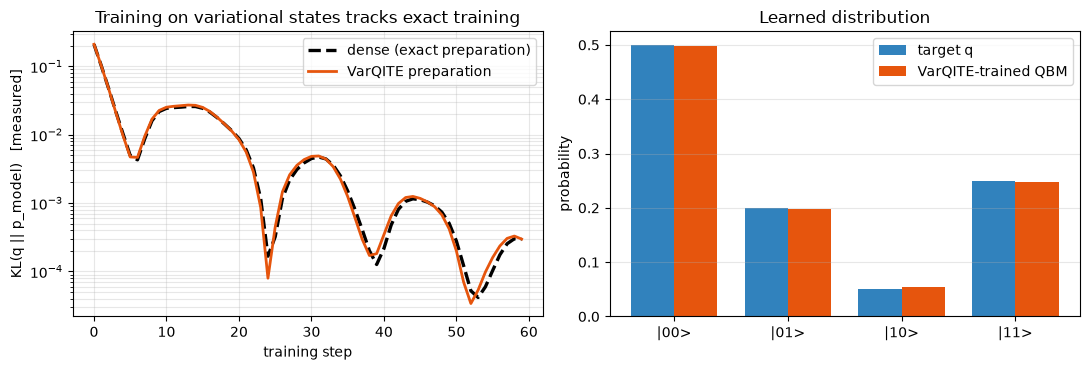

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11.0, 3.8))

ax[0].semilogy(ref.history.monitor, lw=2.4, c="k", ls="--", label="dense (exact preparation)")
ax[0].semilogy(model.history.monitor, lw=2, c="#e6550d", label="VarQITE preparation")
ax[0].set_xlabel("training step"); ax[0].set_ylabel("KL(q || p_model)   [measured]")
ax[0].set_title("Training on variational states tracks exact training")
ax[0].legend(); ax[0].grid(alpha=0.3, which="both")

w = 0.38
idx = np.arange(len(q))
ax[1].bar(idx - w / 2, q, w, label="target q", color="#3182bd")
ax[1].bar(idx + w / 2, model.probabilities(), w, label="VarQITE-trained QBM", color="#e6550d")
ax[1].set_xticks(idx); ax[1].set_xticklabels([f"|{i:02b}>" for i in idx])
ax[1].set_ylabel("probability"); ax[1].set_title("Learned distribution")
ax[1].legend(); ax[1].grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

The two curves lie on top of each other. Preparing every state variationally cost
about 70 ms per step here and changed the answer in the fourth decimal.

**Why so easy?** A *classical* target pushes the model towards a commuting (diagonal)
Hamiltonian: the gradient drives $\langle X_i\rangle_{\rm model}\to\langle X_i\rangle_{\rm data}=0$,
so the transverse terms decay. And on commuting Hamiltonians the tilt-partner ansatz from
notebook 11 is *exact*. Generative modelling of classical data is VarQITE's home turf —
let's confirm that by watching the preparation error during training.

In [4]:
resid = [qbm.FullyVisibleQBM(n=2, connectivity="all", backend=varqite_backend(),
                             theta=th).state().varqite_result().residual
         for th in model.history.theta[::6]]
print("McLachlan residual during generative training:")
print("   step:     " + "".join(f"{6*i:>9d}" for i in range(len(resid))))
print("   residual: " + "".join(f"{r:>9.1e}" for r in resid))
print("\nIt stays at ~1e-6 throughout: the prepared state is essentially exact.")

McLachlan residual during generative training:
   step:             0        6       12       18       24       30       36       42       48       54
   residual:   1.5e-06  3.6e-05  6.5e-05  2.8e-05  8.9e-06  7.9e-06  8.2e-06  8.1e-06  2.1e-06  6.9e-06

It stays at ~1e-6 throughout: the prepared state is essentially exact.


### With a finite shot budget

Now the honest hardware version: every expectation is estimated from a finite number of
measurements. Two things to know.

* Sampling noise enters the **gradient**, so use plain gradient descent, not Adam —
  Adam rescales by the gradient magnitude, which turns noise into full-size steps and
  makes training a random walk (the same lesson as `qbm.sampling`). Every curve below
  uses plain GD, including the noiseless one, so the only variable is the shot budget.
* The KL we plot is computed exactly here for a clean picture; on a device you would
  estimate it from `model.sample(...)`, which adds its own error on top.

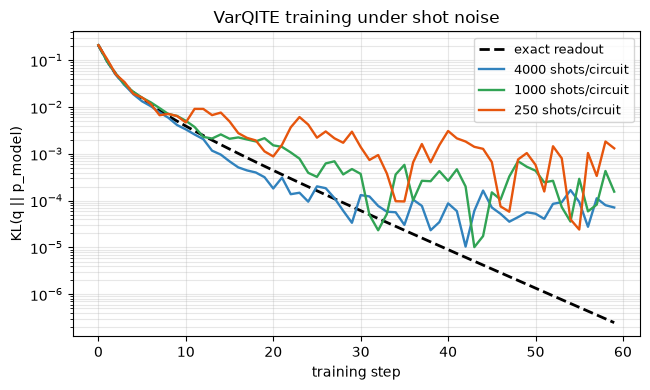

   shots= None   final KL = 2.47e-07   mean of last 10 = 6.66e-07
   shots= 4000   final KL = 7.15e-05   mean of last 10 = 8.26e-05
   shots= 1000   final KL = 1.56e-04   mean of last 10 = 2.08e-04
   shots=  250   final KL = 1.32e-03   mean of last 10 = 7.60e-04


In [5]:
# same optimizer everywhere, so the only thing changing is the shot budget
shot_runs = {}
for shots in (None, 4000, 1000, 250):
    shot_runs[shots] = qbm.learn(q, steps=60, optimizer=qbm.optim.GradientDescent(lr=0.35),
                                 backend=varqite_backend(shots=shots, seed=1))

fig, ax = plt.subplots(figsize=(6.6, 4.0))
colors = {None: "k", 4000: "#3182bd", 1000: "#31a354", 250: "#e6550d"}
for shots, m in shot_runs.items():
    lbl = "exact readout" if shots is None else f"{shots} shots/circuit"
    ax.semilogy(np.maximum(m.history.monitor, 1e-9), lw=2 if shots is None else 1.7,
                ls="--" if shots is None else "-", c=colors[shots], label=lbl)
ax.set_xlabel("training step"); ax.set_ylabel("KL(q || p_model)")
ax.set_title("VarQITE training under shot noise")
ax.legend(fontsize=9); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

for shots, m in shot_runs.items():
    print(f"   shots={str(shots):>5s}   final KL = {m.history.monitor[-1]:.2e}   "
          f"mean of last 10 = {np.mean(m.history.monitor[-10:]):.2e}")

## Part 2 — Ground-state energy: where it gets hard

Generative modelling was the easy case. Ground-state search is the opposite, and for a
structural reason:

> Minimising $\langle H\rangle$ drives the QBM to **low effective temperature**. But
> $\rho \to$ a pure state means the thermofield double becomes highly entangled, and that
> is exactly the regime a shallow variational preparation cannot reach.

The task fights the method. Everything here is measurable (the value *and* the gradient,
via the Hadamard-test estimators), so this is a genuine end-to-end quantum run — it just
has a floor, and then a cliff.

In [6]:
H  = qbm.hamiltonians.tfim(2, J=1.0, g=1.2)
E0 = np.linalg.eigvalsh(H)[0]

def ground_run(backend, steps=150, stop=None, lr=0.2, seed=0):
    m = qbm.FullyVisibleQBM(n=2, connectivity="all", backend=backend)
    m.theta = np.random.default_rng(seed).normal(scale=0.05, size=m.n_params)
    h = qbm.fit(m, Energy(H), qbm.optim.Adam(lr=lr), steps=steps, stop=stop,
                monitor=(None if backend is None else
                         (lambda s, mo: s.varqite_result().residual)))
    return m, h

_, hd      = ground_run(None)                                # dense reference
_, h_long  = ground_run(varqite_backend(depth=3))            # VarQITE, unguarded
E_long, R_long = h_long.loss, h_long.monitor

print(f"exact ground energy       {E0:+.6f}")
print(f"dense, 150 steps          {hd.loss[-1]:+.6f}   error {abs(hd.loss[-1]-E0):.2e}")
print(f"VarQITE depth 3, 150      {E_long[-1]:+.6f}   error {abs(E_long[-1]-E0):.2e}  <-- ?!")
print(f"  ... but its best was    {min(E_long):+.6f}   error {abs(min(E_long)-E0):.2e}")

exact ground energy       -2.600000
dense, 150 steps          -2.592173   error 7.83e-03
VarQITE depth 3, 150      +0.548250   error 3.15e+00  <-- ?!
  ... but its best was    -2.586627   error 1.34e-02


Something went wrong late in the run. Let's plot the energy next to the preparation
error and see it happen.

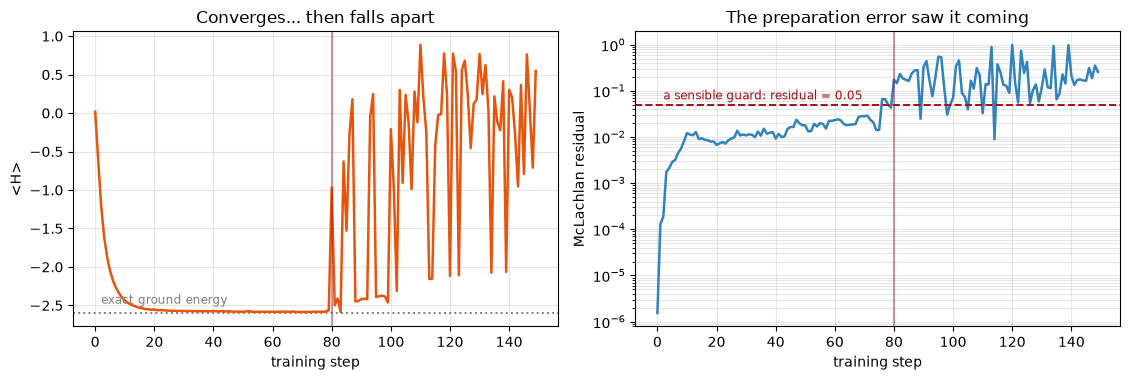

residual crosses 0.1 at step 80 (red line)
best energy reached at step 70: <H> = -2.58663, error 1.34e-02
by step 150 the run has wandered to <H> = +0.5482


In [7]:
# where does the preparation stop being trustworthy?
crossed = int(np.argmax(np.array(R_long) > 0.1))

fig, ax = plt.subplots(1, 2, figsize=(11.4, 3.9))
ax[0].axhline(E0, color="grey", ls=":", lw=1.4)
ax[0].text(2, E0 + 0.12, "exact ground energy", color="grey", fontsize=8.5)
ax[0].plot(E_long, lw=1.8, c="#e6550d")
ax[0].set_xlabel("training step"); ax[0].set_ylabel("<H>")
ax[0].set_title("Converges... then falls apart")
ax[0].grid(alpha=0.3)

ax[1].semilogy(R_long, lw=1.8, c="#3182bd")
ax[1].axhline(0.05, color="#a50f15", ls="--", lw=1.4)
ax[1].text(2, 0.065, "a sensible guard: residual = 0.05", color="#a50f15", fontsize=8.5)
ax[1].set_xlabel("training step"); ax[1].set_ylabel("McLachlan residual")
ax[1].set_title("The preparation error saw it coming")
ax[1].grid(alpha=0.3, which="both")
for a in ax:
    a.axvline(crossed, color="#a50f15", lw=1.1, alpha=0.55)
plt.tight_layout(); plt.show()

best_step = int(np.argmin(E_long))
print(f"residual crosses 0.1 at step {crossed} (red line)")
print(f"best energy reached at step {best_step}: <H> = {E_long[best_step]:+.5f}, "
      f"error {abs(E_long[best_step]-E0):.2e}")
print(f"by step 150 the run has wandered to <H> = {E_long[-1]:+.4f}")

This is worth being precise about, because it is a property of the *method*, not a bug.

As $\theta$ grows the target state becomes colder, the ansatz represents less and less of
the imaginary-time flow, and the gradient it produces slowly stops pointing where the
exact gradient points. Past roughly `residual ≈ 0.1` the update is wrong enough to push
$\theta$ further out — which makes preparation worse still. It is a feedback loop, and it
is visible in the residual **before** it is visible in the energy.

So the fix is exactly the diagnostic. `fit(..., stop=...)` halts on any condition you can
measure:

exact ground energy -2.60000

preparation       stopped at        <H>      error   best <H>      error
------------------------------------------------------------------------
VarQITE depth 1            3   -1.16085   1.44e+00   -1.16085   1.44e+00


VarQITE depth 2            8   -2.26477   3.35e-01   -2.26477   3.35e-01


VarQITE depth 3           77   -2.58344   1.66e-02   -2.58663   1.34e-02


VarQITE depth 4          150   -2.58675   1.32e-02   -2.59340   6.60e-03
dense (exact)            150   -2.59217   7.83e-03


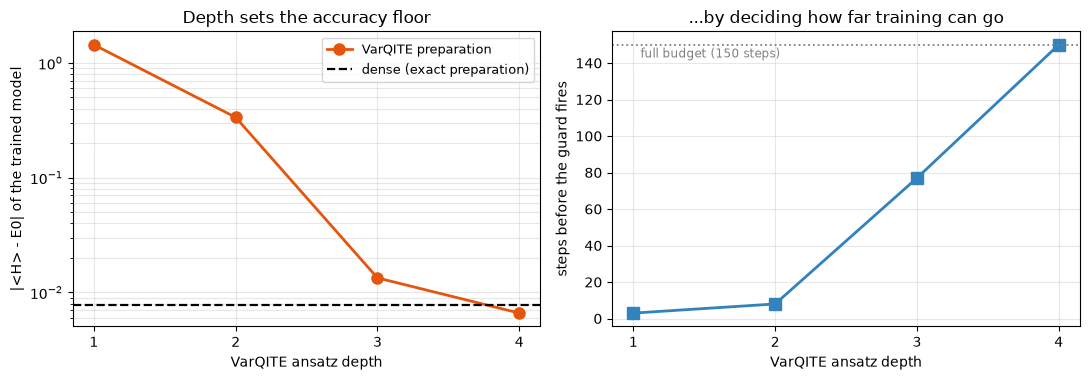

In [8]:
guard = lambda state, mdl: state.varqite_result().residual > 0.05

print(f"exact ground energy {E0:+.5f}\n")
print(f"{'preparation':16s} {'stopped at':>11s} {'<H>':>10s} {'error':>10s} {'best <H>':>10s}"
      f" {'error':>10s}")
print("-" * 72)
depth_err, depth_stop = {}, {}
for d in (1, 2, 3, 4):
    _, h = ground_run(varqite_backend(depth=d), stop=guard)
    b = int(np.argmin(h.loss))
    depth_err[d], depth_stop[d] = abs(h.loss[b] - E0), len(h)
    print(f"VarQITE depth {d:<2d} {len(h):11d} {h.loss[-1]:10.5f} {abs(h.loss[-1]-E0):10.2e}"
          f" {h.loss[b]:10.5f} {depth_err[d]:10.2e}")
print(f"{'dense (exact)':16s} {len(hd):11d} {hd.loss[-1]:10.5f} {abs(hd.loss[-1]-E0):10.2e}")

fig, ax = plt.subplots(1, 2, figsize=(11.0, 3.9))
ax[0].semilogy([1, 2, 3, 4], [depth_err[d] for d in (1, 2, 3, 4)], "o-", lw=2, ms=8,
               c="#e6550d", label="VarQITE preparation")
ax[0].axhline(abs(hd.loss[-1] - E0), color="k", ls="--", lw=1.6, label="dense (exact preparation)")
ax[0].set_xticks([1, 2, 3, 4]); ax[0].set_xlabel("VarQITE ansatz depth")
ax[0].set_ylabel("|<H> - E0| of the trained model")
ax[0].set_title("Depth sets the accuracy floor")
ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3, which="both")

ax[1].plot([1, 2, 3, 4], [depth_stop[d] for d in (1, 2, 3, 4)], "s-", lw=2, ms=8, c="#3182bd")
ax[1].axhline(150, color="grey", ls=":", lw=1.3)
ax[1].text(1.05, 143, "full budget (150 steps)", color="grey", fontsize=8.5)
ax[1].set_xticks([1, 2, 3, 4]); ax[1].set_xlabel("VarQITE ansatz depth")
ax[1].set_ylabel("steps before the guard fires")
ax[1].set_title("...by deciding how far training can go")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Part 3 — What it costs

Nothing here is free, and the bill is dominated by preparation: a VarQITE run per
training step, and $O(L^2)$ circuits per time step inside it. Worth seeing in full before
planning a hardware experiment.

In [9]:
state = varqite_backend(depth=3, steps=40, shots=1000).thermal_state(
    model.ham, model.theta)
est = state.resource_estimate()
per_step = est["circuits_for_preparation"]

print("one training step, 2-qubit QBM, depth 3 / 40 time steps, 1000 shots")
for k in ("n_qubits", "prep_gates", "prep_depth", "circuits_for_preparation"):
    print(f"   {k:26s} {est[k]:>12,}")
print(f"   {'circuits per gradient':26s} {est['circuits_per_gradient']:>12,}   "
      "(generative gradients need none of these -- just <G_j>)")
print(f"\n60 training steps  ->  {60 * per_step:,} preparation circuits")
print(f"                       {60 * per_step * 1000:,} shots at 1000 shots/circuit")

print("\nwall-clock on this laptop (simulated):")
for tag, be in [("dense", None), ("VarQITE d2/s25", varqite_backend(2, 25)),
                ("VarQITE d3/s40", varqite_backend(3, 40))]:
    t0 = time.time()
    qbm.learn(q, steps=30, lr=0.15, backend=be)
    print(f"   {tag:16s} {(time.time() - t0) / 30 * 1000:6.0f} ms / training step")

one training step, 2-qubit QBM, depth 3 / 40 time steps, 1000 shots
   n_qubits                              5
   prep_gates                          136
   prep_depth                           74
   circuits_for_preparation         25,800
   circuits per gradient                40   (generative gradients need none of these -- just <G_j>)

60 training steps  ->  1,548,000 preparation circuits
                       1,548,000,000 shots at 1000 shots/circuit

wall-clock on this laptop (simulated):
   dense                 0 ms / training step


   VarQITE d2/s25       26 ms / training step


   VarQITE d3/s40       79 ms / training step


## When to reach for this

**Use VarQITE training when**

* the target is a genuine finite-temperature state — generative modelling, thermal
  physics, anything where $\rho$ stays mixed. This is the regime it was built for, and
  it costs you almost nothing in accuracy;
* you need a pipeline that will run on a device: no eigendecomposition, gate-level
  circuits, OpenQASM export;
* you want the preparation error reported rather than assumed.

**Be careful when**

* the objective drives $\beta \to \infty$ (ground states, near-pure targets). It still
  works to ~1%, but guard it — `stop=` on the residual, and keep the best iterate;
* you are using a stochastic gradient. Plain gradient descent, not Adam;
* the parameter count is large. Preparation is $O(L^2)$ circuits per time step, and $L$
  grows with both the Hamiltonian's term count and the ansatz depth.

**The checklist**

```python
backend = CircuitBackend(gibbs_prep="varqite",
                         varqite_options={"depth": 3, "steps": 40})

model = qbm.learn(data, backend=backend, steps=60)      # generative: just works

h = qbm.fit(model, Energy(H), qbm.optim.Adam(lr=0.2), steps=150,   # harder objectives:
            monitor=lambda s, m: s.varqite_result().residual,      #   watch it
            stop=lambda s, m: s.varqite_result().residual > 0.05)  #   and guard it
```

## Recap

* A QBM can be trained **entirely on variationally prepared thermal states** — no
  eigendecomposition in the loop, every gradient a measured expectation value.
* On classical generative targets it is indistinguishable from exact training, because
  the model flows to a commuting Hamiltonian where the tilt ansatz is exact.
* It survives shot noise, with plain gradient descent.
* On ground-state search the preparation degrades as $\beta$ grows, setting an accuracy
  floor (fixed by depth) and eventually destabilising training (fixed by guarding on the
  residual).
* The residual is what makes all of this manageable: it is measurable, it tracks the true
  error, and it moves *first*.